In [1]:
import datetime, os
from typing import Literal, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from sklearn.preprocessing import StandardScaler
from torch.utils.data import Dataset, DataLoader
from torchmetrics.regression import MeanAbsolutePercentageError

import warnings
warnings.filterwarnings("ignore")


In [2]:
SEED = 42
PLOT_DPI = 100

DEVICE = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

np.random.seed(SEED)

In [3]:
path = "/home/ltimindtree/Documents/personal/code/AIMLCZG628T/datasets/Skoltech_Anomaly_Benchmark/preprocessed_skab_dataset_set2.csv"

dataframe = pd.read_csv(path)
dataframe.set_index(pd.to_datetime(dataframe.datetime), drop=True, inplace=True)
dataframe.drop(columns=["datetime"], inplace=True)
dataframe.head()

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,Electrical_Resistence,Flow_Resistance,...,Engine_Temperature_pu_Power,Efficiency_Temperature_Difference_Ratio,AccelerometerRMS_Fluctuation,Temperature_Fluctuation,Thermocouple_Fluctuation,Volume Flow RateRMS_Fluctuation,Hydraulic_Power_Fluctuation,Electrical_Power_Fluctuation,anomaly,description
datetime,,,,,,,,,,,,,,,,,,,,,
2020-02-08 13:30:47,0.202394,0.275154,2.16975,1.402774,90.6454,26.8508,238.852,122.664,110.082728,0.011436,...,0.205773,0.010205,0.000339,0.06556,0.004268,0.23928,42.844684,64.762931,0.0,No Anomaly
2020-02-08 13:30:48,0.203153,0.277857,2.07999,0.746920,90.7978,26.8639,227.943,122.338,109.588508,0.006105,...,0.225304,0.005911,0.000339,0.06556,0.004268,0.23928,42.844684,64.762931,0.0,No Anomaly
2020-02-08 13:30:49,0.203153,0.277857,2.07999,0.746920,90.7978,26.8639,227.943,122.338,109.588508,0.006105,...,0.225304,0.005911,0.000339,0.06556,0.004268,0.23928,42.844684,64.762931,0.0,No Anomaly
2020-02-08 13:30:50,0.202054,0.275790,2.52577,1.402774,90.7730,26.8603,223.486,121.338,88.482324,0.011561,...,0.189188,0.009251,0.000339,0.06556,0.004268,0.23928,42.844684,64.762931,0.0,No Anomaly
2020-02-08 13:30:51,0.203595,0.278101,2.49742,1.074847,90.8424,26.8616,244.904,121.664,98.062801,0.008835,...,0.174736,0.006552,0.000339,0.06556,0.004268,0.23928,42.844684,64.762931,0.0,No Anomaly


In [4]:
dataframe_no_anomaly = dataframe.iloc[np.where(dataframe.anomaly==0)]
dataframe_no_anomaly

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,Electrical_Resistence,Flow_Resistance,...,Engine_Temperature_pu_Power,Efficiency_Temperature_Difference_Ratio,AccelerometerRMS_Fluctuation,Temperature_Fluctuation,Thermocouple_Fluctuation,Volume Flow RateRMS_Fluctuation,Hydraulic_Power_Fluctuation,Electrical_Power_Fluctuation,anomaly,description
datetime,,,,,,,,,,,,,,,,,,,,,
2020-02-08 13:30:47,0.202394,0.275154,2.169750,1.402774,90.6454,26.8508,238.852,122.6640,110.082728,0.011436,...,0.205773,0.010205,0.000339,0.065560,0.004268,0.239280,42.844684,64.762931,0.0,No Anomaly
2020-02-08 13:30:48,0.203153,0.277857,2.079990,0.746920,90.7978,26.8639,227.943,122.3380,109.588508,0.006105,...,0.225304,0.005911,0.000339,0.065560,0.004268,0.239280,42.844684,64.762931,0.0,No Anomaly
2020-02-08 13:30:49,0.203153,0.277857,2.079990,0.746920,90.7978,26.8639,227.943,122.3380,109.588508,0.006105,...,0.225304,0.005911,0.000339,0.065560,0.004268,0.239280,42.844684,64.762931,0.0,No Anomaly
2020-02-08 13:30:50,0.202054,0.275790,2.525770,1.402774,90.7730,26.8603,223.486,121.3380,88.482324,0.011561,...,0.189188,0.009251,0.000339,0.065560,0.004268,0.239280,42.844684,64.762931,0.0,No Anomaly
2020-02-08 13:30:51,0.203595,0.278101,2.497420,1.074847,90.8424,26.8616,244.904,121.6640,98.062801,0.008835,...,0.174736,0.006552,0.000339,0.065560,0.004268,0.239280,42.844684,64.762931,0.0,No Anomaly
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-03-09 17:14:05,0.027067,0.038430,0.988875,1.073357,69.6731,24.1046,230.729,32.9562,233.324738,0.032569,...,0.359255,0.006671,0.000008,0.051296,0.003156,0.375264,7.244167,28.685529,0.0,No Anomaly
2020-03-09 17:14:06,0.027067,0.038430,0.988875,1.073357,69.6731,24.1046,230.729,32.9562,233.324738,0.032569,...,0.359255,0.006671,0.000005,0.044208,0.003212,0.377068,6.761665,31.409359,0.0,No Anomaly
2020-03-09 17:14:07,0.027582,0.038836,0.588439,1.073357,69.6959,24.1020,233.443,32.0000,396.715717,0.033542,...,0.596906,0.010753,0.000009,0.048716,0.002828,0.377068,5.340617,34.363695,0.0,No Anomaly


In [5]:
dataframe_train = dataframe_no_anomaly.drop(["anomaly", "description"], axis=1)
dataframe_train

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,Electrical_Resistence,Flow_Resistance,...,Vibration_Intensity_Ratio,AccelerometerRMS_pu_Pressure,Engine_Temperature_pu_Power,Efficiency_Temperature_Difference_Ratio,AccelerometerRMS_Fluctuation,Temperature_Fluctuation,Thermocouple_Fluctuation,Volume Flow RateRMS_Fluctuation,Hydraulic_Power_Fluctuation,Electrical_Power_Fluctuation
datetime,,,,,,,,,,,,,,,,,,,,,
2020-02-08 13:30:47,0.202394,0.275154,2.169750,1.402774,90.6454,26.8508,238.852,122.6640,110.082728,0.011436,...,0.735566,0.000454,0.205773,0.010205,0.000339,0.065560,0.004268,0.239280,42.844684,64.762931
2020-02-08 13:30:48,0.203153,0.277857,2.079990,0.746920,90.7978,26.8639,227.943,122.3380,109.588508,0.006105,...,0.731142,0.000461,0.225304,0.005911,0.000339,0.065560,0.004268,0.239280,42.844684,64.762931
2020-02-08 13:30:49,0.203153,0.277857,2.079990,0.746920,90.7978,26.8639,227.943,122.3380,109.588508,0.006105,...,0.731142,0.000461,0.225304,0.005911,0.000339,0.065560,0.004268,0.239280,42.844684,64.762931
2020-02-08 13:30:50,0.202054,0.275790,2.525770,1.402774,90.7730,26.8603,223.486,121.3380,88.482324,0.011561,...,0.732637,0.000459,0.189188,0.009251,0.000339,0.065560,0.004268,0.239280,42.844684,64.762931
2020-02-08 13:30:51,0.203595,0.278101,2.497420,1.074847,90.8424,26.8616,244.904,121.6640,98.062801,0.008835,...,0.732090,0.000465,0.174736,0.006552,0.000339,0.065560,0.004268,0.239280,42.844684,64.762931
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-03-09 17:14:05,0.027067,0.038430,0.988875,1.073357,69.6731,24.1046,230.729,32.9562,233.324738,0.032569,...,0.704309,0.000032,0.359255,0.006671,0.000008,0.051296,0.003156,0.375264,7.244167,28.685529
2020-03-09 17:14:06,0.027067,0.038430,0.988875,1.073357,69.6731,24.1046,230.729,32.9562,233.324738,0.032569,...,0.704309,0.000032,0.359255,0.006671,0.000005,0.044208,0.003212,0.377068,6.761665,31.409359
2020-03-09 17:14:07,0.027582,0.038836,0.588439,1.073357,69.6959,24.1020,233.443,32.0000,396.715717,0.033542,...,0.710228,0.000033,0.596906,0.010753,0.000009,0.048716,0.002828,0.377068,5.340617,34.363695


In [6]:
dataframe_test = dataframe.drop(["anomaly", "description"], axis=1)
dataframe_test

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,Electrical_Resistence,Flow_Resistance,...,Vibration_Intensity_Ratio,AccelerometerRMS_pu_Pressure,Engine_Temperature_pu_Power,Efficiency_Temperature_Difference_Ratio,AccelerometerRMS_Fluctuation,Temperature_Fluctuation,Thermocouple_Fluctuation,Volume Flow RateRMS_Fluctuation,Hydraulic_Power_Fluctuation,Electrical_Power_Fluctuation
datetime,,,,,,,,,,,,,,,,,,,,,
2020-02-08 13:30:47,0.202394,0.275154,2.169750,1.402774,90.6454,26.8508,238.852,122.6640,110.082728,0.011436,...,0.735566,0.000454,0.205773,0.010205,0.000339,0.065560,0.004268,0.239280,42.844684,64.762931
2020-02-08 13:30:48,0.203153,0.277857,2.079990,0.746920,90.7978,26.8639,227.943,122.3380,109.588508,0.006105,...,0.731142,0.000461,0.225304,0.005911,0.000339,0.065560,0.004268,0.239280,42.844684,64.762931
2020-02-08 13:30:49,0.203153,0.277857,2.079990,0.746920,90.7978,26.8639,227.943,122.3380,109.588508,0.006105,...,0.731142,0.000461,0.225304,0.005911,0.000339,0.065560,0.004268,0.239280,42.844684,64.762931
2020-02-08 13:30:50,0.202054,0.275790,2.525770,1.402774,90.7730,26.8603,223.486,121.3380,88.482324,0.011561,...,0.732637,0.000459,0.189188,0.009251,0.000339,0.065560,0.004268,0.239280,42.844684,64.762931
2020-02-08 13:30:51,0.203595,0.278101,2.497420,1.074847,90.8424,26.8616,244.904,121.6640,98.062801,0.008835,...,0.732090,0.000465,0.174736,0.006552,0.000339,0.065560,0.004268,0.239280,42.844684,64.762931
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-03-09 17:14:05,0.027067,0.038430,0.988875,1.073357,69.6731,24.1046,230.729,32.9562,233.324738,0.032569,...,0.704309,0.000032,0.359255,0.006671,0.000008,0.051296,0.003156,0.375264,7.244167,28.685529
2020-03-09 17:14:06,0.027067,0.038430,0.988875,1.073357,69.6731,24.1046,230.729,32.9562,233.324738,0.032569,...,0.704309,0.000032,0.359255,0.006671,0.000005,0.044208,0.003212,0.377068,6.761665,31.409359
2020-03-09 17:14:07,0.027582,0.038836,0.588439,1.073357,69.6959,24.1020,233.443,32.0000,396.715717,0.033542,...,0.710228,0.000033,0.596906,0.010753,0.000009,0.048716,0.002828,0.377068,5.340617,34.363695


In [7]:
scaler = StandardScaler()
dataframe_train_X_scaled = scaler.fit_transform(dataframe_train)
dataframe_train_X_scaled = pd.DataFrame(dataframe_train_X_scaled, columns=dataframe_train.columns)
dataframe_train_X_scaled.index = dataframe_train.index
dataframe_train_X_scaled.head()

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,Electrical_Resistence,Flow_Resistance,...,Vibration_Intensity_Ratio,AccelerometerRMS_pu_Pressure,Engine_Temperature_pu_Power,Efficiency_Temperature_Difference_Ratio,AccelerometerRMS_Fluctuation,Temperature_Fluctuation,Thermocouple_Fluctuation,Volume Flow RateRMS_Fluctuation,Hydraulic_Power_Fluctuation,Electrical_Power_Fluctuation
datetime,,,,,,,,,,,,,,,,,,,,,
2020-02-08 13:30:47,0.809903,1.027618,0.549573,1.179607,1.097214,0.074484,0.846637,0.923277,-0.656812,-0.648243,...,-0.048405,0.877221,-0.621810,0.540857,-0.000453,-0.339719,-0.013514,-0.091388,1.140668,0.466565
2020-02-08 13:30:48,0.817917,1.051719,0.438535,-1.383191,1.113330,0.079879,-0.157370,0.916055,-0.661911,-1.043360,...,-0.105278,0.910539,-0.491338,-0.624895,-0.000453,-0.339719,-0.013514,-0.091388,1.140668,0.466565
2020-02-08 13:30:49,0.817917,1.051719,0.438535,-1.383191,1.113330,0.079879,-0.157370,0.916055,-0.661911,-1.043360,...,-0.105278,0.910539,-0.491338,-0.624895,-0.000453,-0.339719,-0.013514,-0.091388,1.140668,0.466565
2020-02-08 13:30:50,0.806313,1.033289,0.989989,1.179607,1.110708,0.078396,-0.567569,0.893902,-0.879643,-0.638980,...,-0.086061,0.900839,-0.732602,0.281845,-0.000453,-0.339719,-0.013514,-0.091388,1.140668,0.466565
2020-02-08 13:30:51,0.822584,1.053895,0.954919,-0.101792,1.118047,0.078932,1.403631,0.901124,-0.780811,-0.841064,...,-0.093093,0.928418,-0.829145,-0.450715,-0.000453,-0.339719,-0.013514,-0.091388,1.140668,0.466565


In [8]:
dataframe_test_X_scaled = scaler.transform(dataframe_test)
dataframe_test_X_scaled = pd.DataFrame(dataframe_test_X_scaled, columns=dataframe_test.columns)
dataframe_test_X_scaled.index = dataframe_test.index
dataframe_test_X_scaled.head()

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,Electrical_Resistence,Flow_Resistance,...,Vibration_Intensity_Ratio,AccelerometerRMS_pu_Pressure,Engine_Temperature_pu_Power,Efficiency_Temperature_Difference_Ratio,AccelerometerRMS_Fluctuation,Temperature_Fluctuation,Thermocouple_Fluctuation,Volume Flow RateRMS_Fluctuation,Hydraulic_Power_Fluctuation,Electrical_Power_Fluctuation
datetime,,,,,,,,,,,,,,,,,,,,,
2020-02-08 13:30:47,0.809903,1.027618,0.549573,1.179607,1.097214,0.074484,0.846637,0.923277,-0.656812,-0.648243,...,-0.048405,0.877221,-0.621810,0.540857,-0.000453,-0.339719,-0.013514,-0.091388,1.140668,0.466565
2020-02-08 13:30:48,0.817917,1.051719,0.438535,-1.383191,1.113330,0.079879,-0.157370,0.916055,-0.661911,-1.043360,...,-0.105278,0.910539,-0.491338,-0.624895,-0.000453,-0.339719,-0.013514,-0.091388,1.140668,0.466565
2020-02-08 13:30:49,0.817917,1.051719,0.438535,-1.383191,1.113330,0.079879,-0.157370,0.916055,-0.661911,-1.043360,...,-0.105278,0.910539,-0.491338,-0.624895,-0.000453,-0.339719,-0.013514,-0.091388,1.140668,0.466565
2020-02-08 13:30:50,0.806313,1.033289,0.989989,1.179607,1.110708,0.078396,-0.567569,0.893902,-0.879643,-0.638980,...,-0.086061,0.900839,-0.732602,0.281845,-0.000453,-0.339719,-0.013514,-0.091388,1.140668,0.466565
2020-02-08 13:30:51,0.822584,1.053895,0.954919,-0.101792,1.118047,0.078932,1.403631,0.901124,-0.780811,-0.841064,...,-0.093093,0.928418,-0.829145,-0.450715,-0.000453,-0.339719,-0.013514,-0.091388,1.140668,0.466565


In [9]:
BATCH_SIZE = 128
DROPOUT = 0.1
LEARNING_RATE = 0.01

class SKABDataset(Dataset):
    """
    A custom PyTorch Dataset for loading numerical data from a CSV file.
    """
    def __init__(self, dataframe_X: pd.DataFrame):
        self.dataframe_X = dataframe_X

    def __len__(self):
        return len(self.dataframe_X)
    
    def __getitem__(self, idx):
        return torch.tensor(self.dataframe_X.iloc[idx].values, dtype=torch.float32)

train_dataloader = DataLoader(
                                SKABDataset(dataframe_X=dataframe_train_X_scaled),
                                batch_size=BATCH_SIZE, shuffle=True, drop_last=True
)

test_dataloader = DataLoader(
                                SKABDataset(dataframe_X=dataframe_test_X_scaled),
                                batch_size=1, shuffle=True, drop_last=True
)


for batch_id, data in enumerate(train_dataloader, 1):
    print(batch_id, data.shape)
    break

for batch_id, data in enumerate(test_dataloader, 1):
    print(batch_id, data.shape)
    break

1 torch.Size([128, 28])
1 torch.Size([1, 28])


In [10]:
class VariationalAutoencoder(nn.Module):
    """
    A simple Variational Autoencoder (VAE) model.
    The encoder outputs mean (mu) and log-variance (log_var) for the latent distribution.
    A reparameterization trick is used to sample from this distribution.
    """
    def __init__(self, input_dim, latent_dim):
        super(VariationalAutoencoder, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, input_dim * 4), nn.BatchNorm1d(input_dim * 4), nn.LeakyReLU(), nn.Dropout(DROPOUT),
            nn.Linear(input_dim * 4, input_dim * 2), nn.BatchNorm1d(input_dim * 2), nn.LeakyReLU(), nn.Dropout(DROPOUT),
            nn.Linear(input_dim * 2, latent_dim), nn.Sigmoid(),
        )

        self.encoder_mu = nn.Linear(latent_dim, latent_dim)
        self.encoder_log_var = nn.Sequential(
                                                nn.Linear(latent_dim, latent_dim),
                                                nn.Tanh()
        )
        
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, input_dim * 2), nn.BatchNorm1d(input_dim * 2), nn.LeakyReLU(), nn.Dropout(DROPOUT),
            nn.Linear(input_dim * 2, input_dim * 4), nn.BatchNorm1d(input_dim * 4), nn.LeakyReLU(), nn.Dropout(DROPOUT),
            nn.Linear(input_dim * 4, input_dim)
        )
        print(f"Variational Autoencoder initialized with input_dim={input_dim}, latent_dim={latent_dim}")

        self.mse_loss = nn.MSELoss()

    def encode(self, x):
        """Encodes the input into mu and log_var."""
        h1 = self.encoder(x)
        mu = self.encoder_mu(h1)
        log_var = self.encoder_log_var(h1)
        return mu, log_var

    def reparameterize(self, mu, log_var):
        """
        Applies the reparameterization trick to sample from the latent space.
        z = mu + std * epsilon, where epsilon is N(0,1).
        """
        std = torch.exp(0.5 * log_var) # Standard deviation
        epsilon = torch.randn_like(std) # Sample from standard normal distribution
        return mu + (epsilon * std)

    def decode(self, z):
        """Decodes the latent vector back to the original input space."""
        return self.decoder(z)

    def forward(self, x):
        mu, log_var = self.encode(x)
        z = self.reparameterize(mu, log_var)
        reconstruction = self.decode(z)
        return reconstruction, mu, log_var
    
    def reconstruction_loss(self, recomstructed_samples, real_samples, mu, log_var):
        L_prior = torch.mean(-0.5 * torch.sum(1 + log_var - mu ** 2 -log_var.exp(), dim=1), dim=0)
        L_reconstruction = L_prior + self.mse_loss(recomstructed_samples, real_samples)
        return L_reconstruction
    
vae_model = VariationalAutoencoder(input_dim=dataframe_test_X_scaled.shape[1], latent_dim=dataframe_test_X_scaled.shape[1]//2)

Variational Autoencoder initialized with input_dim=28, latent_dim=14


In [11]:
EPOCHS = 1000
L1_REGULARIZATION = True
L2_REGULARIZATION = True

vae_model = vae_model.to(DEVICE)
vae_model = vae_model.train()

mse_loss_function = nn.MSELoss().double().to(DEVICE)
mae_loss_function = nn.L1Loss().double().to(DEVICE)
mape_loss_function = MeanAbsolutePercentageError().double().to(DEVICE)
rmse_loss_function = lambda predictions, targets: torch.sqrt(mse_loss_function(predictions, targets)).to(DEVICE)

optimizer = torch.optim.Adam(vae_model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5 if L2_REGULARIZATION else 0)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=25, gamma=0.95)
# lr_scheduler = torch.optim.lr_schedule.ExponentialLR(optimizer, gamma=0.999)

def train_test(model, iteration, dataloader=None, mode="Training", l1_lambda=1e-5):
    total_loss, average_loss = 0, 0
    
    bar_postfix = dict()
    bar_desc, bar_color =  f"Epoch {iteration:03d} |  {mode}", "red"
    if mode == "Training": 
        bar_desc, bar_color =  f"Epoch {iteration:03d} | {mode}", "green"

    bar = tqdm.tqdm(dataloader, total = len(dataloader), desc=bar_desc, unit=" batches", colour=bar_color)
    for idx, data in enumerate(bar, 1):

        data = data.to(DEVICE)
        reconstructed_data, mu, log_var = model(data)
        mse_loss = mse_loss_function(reconstructed_data, data)
        mae_loss = mae_loss_function(reconstructed_data, data)
        rmse_loss = rmse_loss_function(reconstructed_data, data)
        
        # KL Divergence Loss: D_KL(N(mu, sigma^2) || N(0, 1))
        # -0.5 * sum(1 + log(sigma^2) - mu^2 - sigma^2)
        kl_divergence = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())

        total_loss = model.reconstruction_loss(reconstructed_data, data, mu, log_var)

        bar_postfix["MSE"] = f"{mse_loss.item():0.3f}"
        bar_postfix["MAE"] = f"{mae_loss.item():0.3f}"
        bar_postfix["RMSE"] = f"{rmse_loss.item():0.3f}"
        bar_postfix["KLD"] = f"{kl_divergence.item():0.3f}"
        bar_postfix["LR"] = f"{lr_scheduler.get_lr()[-1]:0.5f}"
        bar.set_postfix(bar_postfix)
        bar.refresh()
        
    return bar_postfix, total_loss

train_history, val_history = list(), list()

for epoch, _ in enumerate(range(EPOCHS), 1):
    vae_model = vae_model.train()
    
    history, train_loss = train_test(vae_model, iteration=epoch, dataloader=train_dataloader, mode="Training")
    train_history.append(history)
    
    optimizer.zero_grad()
    train_loss.backward()
    optimizer.step()
    lr_scheduler.step()


# --- Optional: Save the trained model ---
model_save_path = '/home/ltimindtree/Documents/personal/code/AIMLCZG628T/models/autoencoder_model_VAE.pth'
torch.save(vae_model.state_dict(), model_save_path)
print(f"Model saved to {model_save_path}")

Epoch 001 | Training: 100%|██████████| 274/274 [00:04<00:00, 56.95 batches/s, MSE=1.059, MAE=0.837, RMSE=1.029, KLD=182.738, LR=0.01000]
Epoch 002 | Training: 100%|██████████| 274/274 [00:04<00:00, 57.64 batches/s, MSE=0.972, MAE=0.813, RMSE=0.986, KLD=105.929, LR=0.01000]
Epoch 003 | Training: 100%|██████████| 274/274 [00:05<00:00, 53.91 batches/s, MSE=1.854, MAE=0.805, RMSE=1.362, KLD=60.737, LR=0.01000]
Epoch 004 | Training: 100%|██████████| 274/274 [00:04<00:00, 56.22 batches/s, MSE=1.025, MAE=0.822, RMSE=1.012, KLD=36.017, LR=0.01000]
Epoch 005 | Training: 100%|██████████| 274/274 [00:04<00:00, 56.30 batches/s, MSE=1.025, MAE=0.817, RMSE=1.012, KLD=22.601, LR=0.01000]
Epoch 006 | Training: 100%|██████████| 274/274 [00:04<00:00, 58.77 batches/s, MSE=0.957, MAE=0.807, RMSE=0.978, KLD=14.285, LR=0.01000]
Epoch 007 | Training: 100%|██████████| 274/274 [00:05<00:00, 54.68 batches/s, MSE=0.922, MAE=0.790, RMSE=0.960, KLD=9.923, LR=0.01000] 
Epoch 008 | Training: 100%|██████████| 274/274

Model saved to /home/ltimindtree/Documents/personal/code/AIMLCZG628T/models/autoencoder_model_VAE.pth


In [12]:
train_history_dataframe = dict()
train_history_dataframe["Mean Absolute Error"] = list()
# train_history_dataframe["Mean Absolute Percentage Error"] = list()
train_history_dataframe["Mean Squared Error"] = list()
train_history_dataframe["Root Mean Squared Error"] = list()
# train_history_dataframe["Learning Rate"] = list()

for history in train_history:
    train_history_dataframe["Mean Absolute Error"].append(float(history["MAE"]))
    # train_history_dataframe["Mean Absolute Percentage Error"].append(float(history["MAPE"]))
    train_history_dataframe["Mean Squared Error"].append(float(history["MSE"]))
    train_history_dataframe["Root Mean Squared Error"].append(float(history["RMSE"]))
    # train_history_dataframe["Learning Rate"].append(float(history["LR"]))

train_history_dataframe = pd.DataFrame(train_history_dataframe, columns=train_history_dataframe.keys())

# val_history_dataframe = dict()
# val_history_dataframe["Mean Absolute Error"] = list()
# # val_history_dataframe["Mean Absolute Percentage Error"] = list()
# val_history_dataframe["Mean Squared Error"] = list()
# val_history_dataframe["Root Mean Squared Error"] = list()
# # val_history_dataframe["Learning Rate"] = list()

# for history in val_history:
#     val_history_dataframe["Mean Absolute Error"].append(float(history["MAE"]))
#     # val_history_dataframe["Mean Absolute Percentage Error"].append(float(history["MAPE"]))
#     val_history_dataframe["Mean Squared Error"].append(float(history["MSE"]))
#     val_history_dataframe["Root Mean Squared Error"].append(float(history["RMSE"]))
#     # val_history_dataframe["Learning Rate"].append(float(history["LR"]))

# val_history_dataframe = pd.DataFrame(val_history_dataframe, columns=val_history_dataframe.keys())

In [13]:
train_history_dataframe

,Mean Absolute Error,Mean Squared Error,Root Mean Squared Error
0,0.837,1.059,1.029
1,0.813,0.972,0.986
2,0.805,1.854,1.362
3,0.822,1.025,1.012
4,0.817,1.025,1.012
...,...,...,...
995,0.780,0.870,0.933
996,0.767,0.865,0.930
997,0.764,0.840,0.916
998,0.765,0.891,0.944


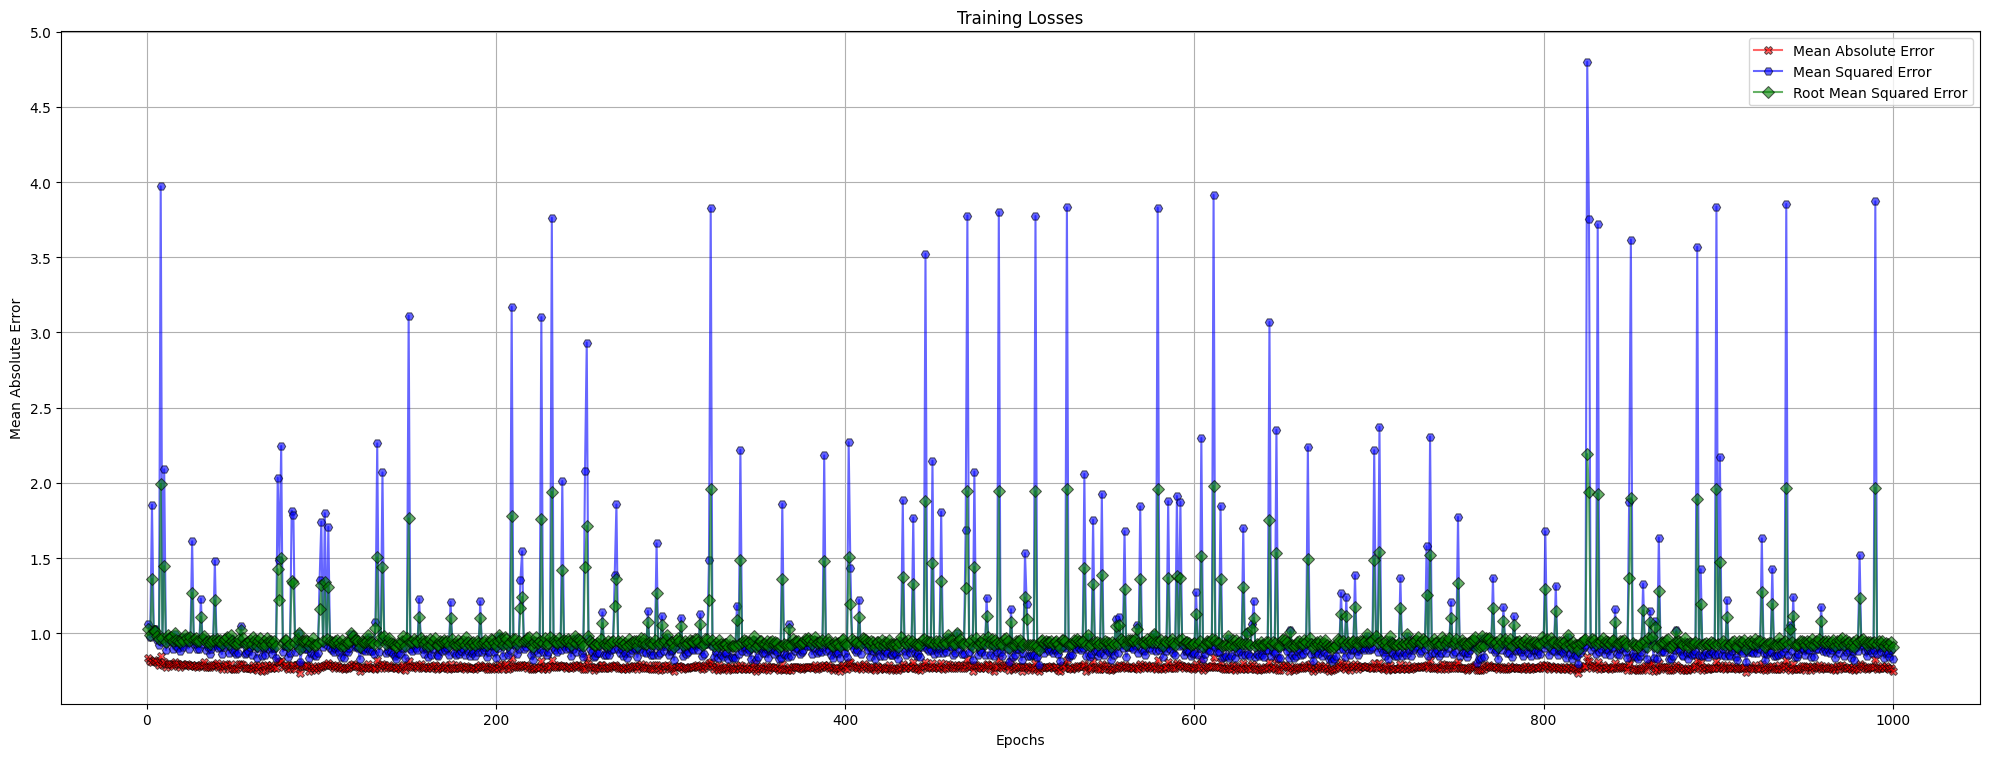

In [14]:
fig, axs = plt.subplots(1, 1, figsize=(20, 8), sharey=True, dpi=PLOT_DPI)

sns.lineplot(
                y="Mean Absolute Error", 
                x=range(1, train_history_dataframe.shape[0]+1), 
                data=train_history_dataframe, 
                marker='X', markersize=6, alpha=0.6, 
                legend='brief', label="Mean Absolute Error",
                color="red", markeredgecolor="black", ax=axs)

sns.lineplot(
                y="Mean Squared Error", 
                x=range(1, train_history_dataframe.shape[0]+1), 
                data=train_history_dataframe, 
                marker='H', markersize=6, alpha=0.6, 
                legend='brief', label="Mean Squared Error",
                color="blue", markeredgecolor="black", ax=axs)

sns.lineplot(
                y="Root Mean Squared Error", 
                x=range(1, train_history_dataframe.shape[0]+1), 
                data=train_history_dataframe, 
                marker='D', markersize=6, alpha=0.6, 
                legend='brief', label="Root Mean Squared Error",
                color="green", markeredgecolor="black", ax=axs)

axs.grid(True)
axs.set_xlabel("Epochs")
axs.set_title("Training Losses")

# sns.lineplot(
#                 y="Mean Absolute Error", 
#                 x=range(1, EPOCHS+1), 
#                 data=val_history_dataframe, 
#                 marker='X', markersize=6, alpha=0.6, 
#                 legend='brief', label="Mean Absolute Error",
#                 color="red", markeredgecolor="black", ax=axs[1])

# sns.lineplot(
#                 y="Mean Squared Error", 
#                 x=range(1, EPOCHS+1), 
#                 data=val_history_dataframe, 
#                 marker='H', markersize=6, alpha=0.6, 
#                 legend='brief', label="Mean Squared Error",
#                 color="blue", markeredgecolor="black", ax=axs[1])

# sns.lineplot(
#                 y="Root Mean Squared Error", 
#                 x=range(1, EPOCHS+1), 
#                 data=val_history_dataframe, 
#                 marker='D', markersize=6, alpha=0.6, 
#                 legend='brief', label="Root Mean Squared Error",
#                 color="green", markeredgecolor="black", ax=axs[1])

# axs[1].grid(True)
# axs[1].set_xlabel("Epochs")
# axs[1].set_title("Validation Losses")


plt.tight_layout(rect=[0, 0, 1, 0.96]) # Adjust layout to prevent title overlap
plt.show()

In [20]:
def model_inference(model, iteration, dataloader=None, mode="Training"):
    
    reconstructed_loss = dict()
    reconstructed_loss["MSE"] = list()
    reconstructed_loss["MAE"] = list()
    reconstructed_loss["RMSE"] = list()
    reconstructed_loss["RE"] = list()
    
    bar_postfix = dict()
    bar_desc, bar_color =  f"Epoch {iteration:03d} |  {mode}", "red"
    if mode == "Training": 
        bar_desc, bar_color =  f"Epoch {iteration:03d} | {mode}", "green"

    bar = tqdm.tqdm(dataloader, total = len(dataloader), desc=bar_desc, unit=" batches", colour=bar_color)
    for idx, data in enumerate(bar, 1):

        data = data.to(DEVICE)
        reconstructed_data, mu, log_var = model(data)
        mse_loss = mse_loss_function(reconstructed_data, data)
        mae_loss = mae_loss_function(reconstructed_data, data)
        rmse_loss = rmse_loss_function(reconstructed_data, data)

        re = model.reconstruction_loss(reconstructed_data, data, mu, log_var) - mse_loss

        reconstructed_loss["MSE"].append(mse_loss.item())
        reconstructed_loss["MAE"].append(mae_loss.item())
        reconstructed_loss["RMSE"].append(rmse_loss.item())
        reconstructed_loss["RE"].append(re.item())

        bar_postfix["MSE"] = f"{mse_loss.item():0.3f}"
        bar_postfix["MAE"] = f"{mae_loss.item():0.3f}"
        bar_postfix["RMSE"] = f"{rmse_loss.item():0.3f}"
        bar.set_postfix(bar_postfix)
        bar.refresh()
        
    return reconstructed_loss

In [21]:
vae_model = vae_model.eval()
reconstructed_loss = model_inference(vae_model, 0, test_dataloader)

Epoch 000 | Training: 100%|██████████| 49202/49202 [01:42<00:00, 482.26 batches/s, MSE=0.813, MAE=0.802, RMSE=0.901]       


In [22]:
reconstructed_loss_dataframe = pd.DataFrame(reconstructed_loss)
reconstructed_loss_dataframe.index = dataframe.index
reconstructed_loss_dataframe = pd.concat([reconstructed_loss_dataframe, dataframe[["anomaly", "description"]]], axis=1)
reconstructed_loss_dataframe

,MSE,MAE,RMSE,RE,anomaly,description
datetime,,,,,,
2020-02-08 13:30:47,0.790962,0.740966,0.889360,0.000037,0.0,No Anomaly
2020-02-08 13:30:48,0.662132,0.655559,0.813715,0.000035,0.0,No Anomaly
2020-02-08 13:30:49,0.940405,0.841578,0.969745,0.000040,0.0,No Anomaly
2020-02-08 13:30:50,1.000269,0.832238,1.000134,0.000051,0.0,No Anomaly
2020-02-08 13:30:51,0.830188,0.719270,0.911147,0.000042,0.0,No Anomaly
...,...,...,...,...,...,...
2020-03-09 17:14:05,0.672976,0.693130,0.820351,0.000044,0.0,No Anomaly
2020-03-09 17:14:06,0.598802,0.660951,0.773823,0.000044,0.0,No Anomaly
2020-03-09 17:14:07,1.165364,0.868689,1.079520,0.000041,0.0,No Anomaly


In [32]:
def plot_timeseries_with_anomaly(df, columns, title=None):
    fig, axs = plt.subplots(len(columns), 1, figsize=(20, len(columns)*6), sharex=False, dpi=PLOT_DPI)
    # plt.subplots_adjust(hspace=0.5)

    # if title: plt.suptitle(title, fontsize=20) # Used suptitle for overall title

    for ax, column in enumerate(columns):
        sns.lineplot(data=df, x=df.index, y=column, alpha=0.6, label=column, ax=axs[ax])
        axs[ax].set_title(f"Time Series of {column}", weight="bold")
        axs[ax].set_ylim(0, 5)

        faulty_points = df.copy()
        # faulty_points = df[df["anomaly"]!=0.0]
        sns.scatterplot(data=faulty_points, x=faulty_points.index, y=column, hue="description", style="description", edgecolor="black", zorder=5, ax=axs[ax])

    plt.tight_layout(rect=[0, 0, 1, 0.96]) # Adjust layout to prevent title overlap

    # plt.savefig(f"../../datasets/Skoltech_Anomaly_Benchmark/plots/{title}.png", format="png")
    plt.show()

In [36]:
reconstructed_loss_dataframe.to_csv("re_vae.csv", index=True)

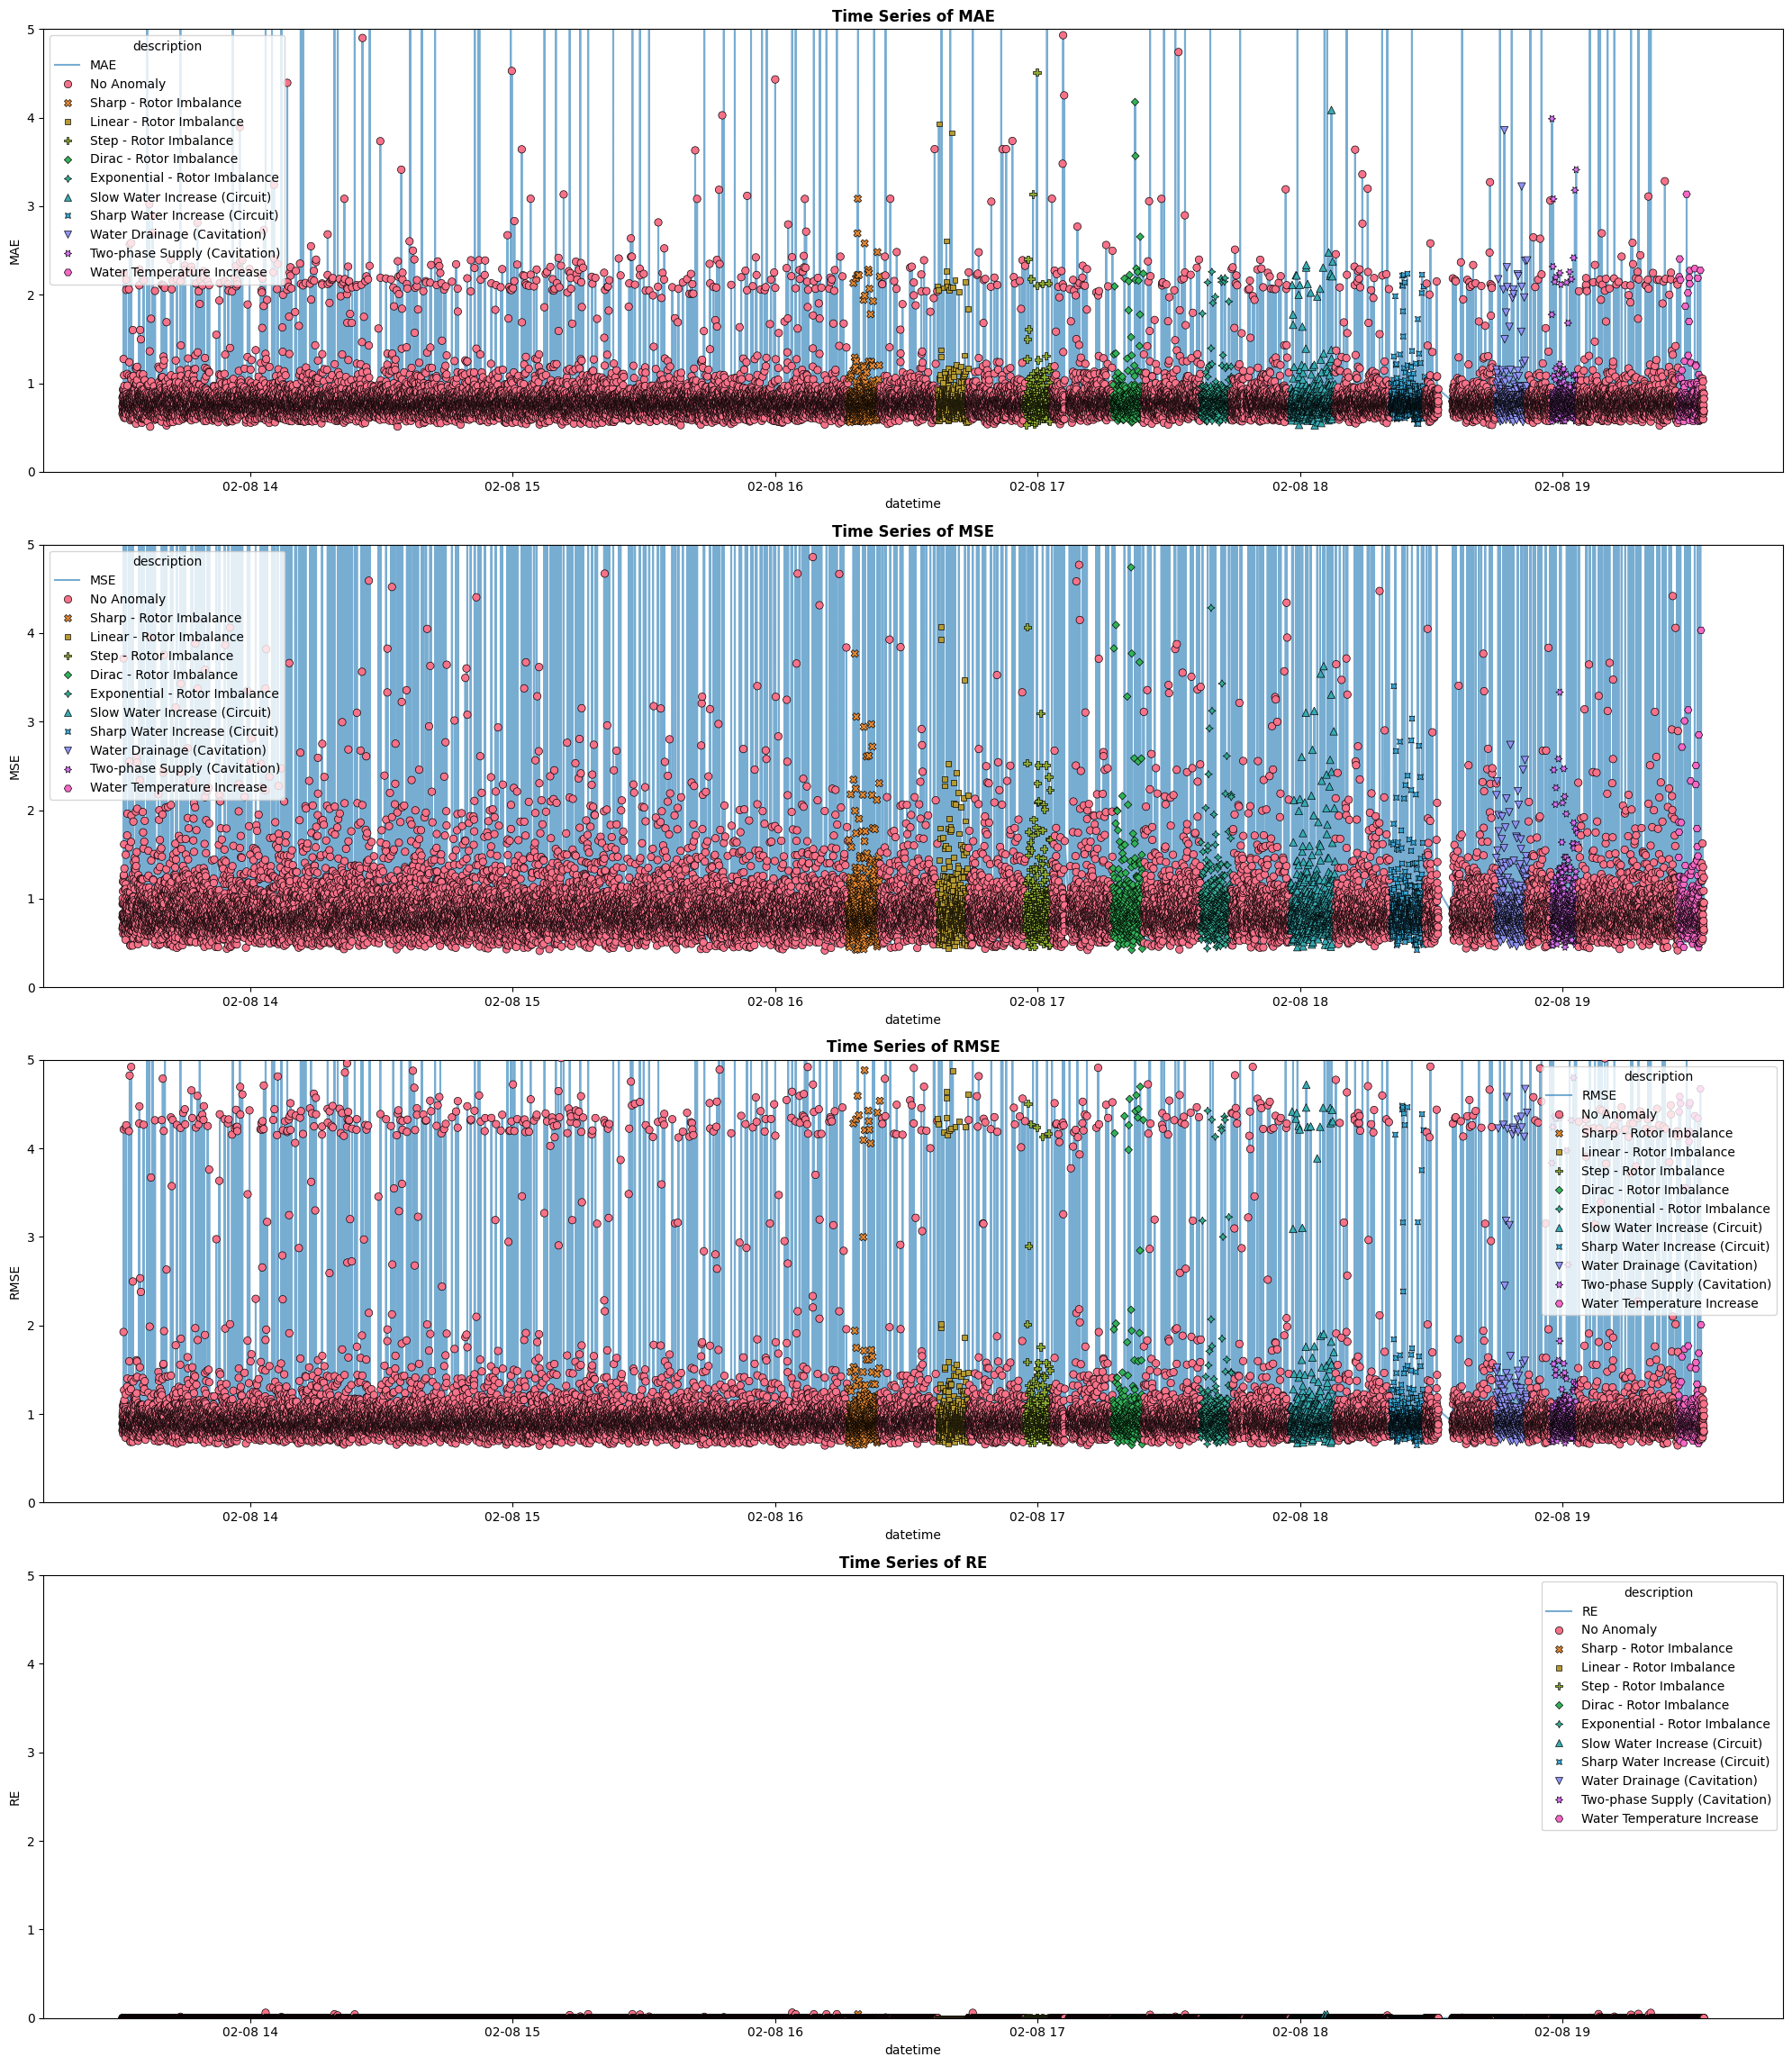

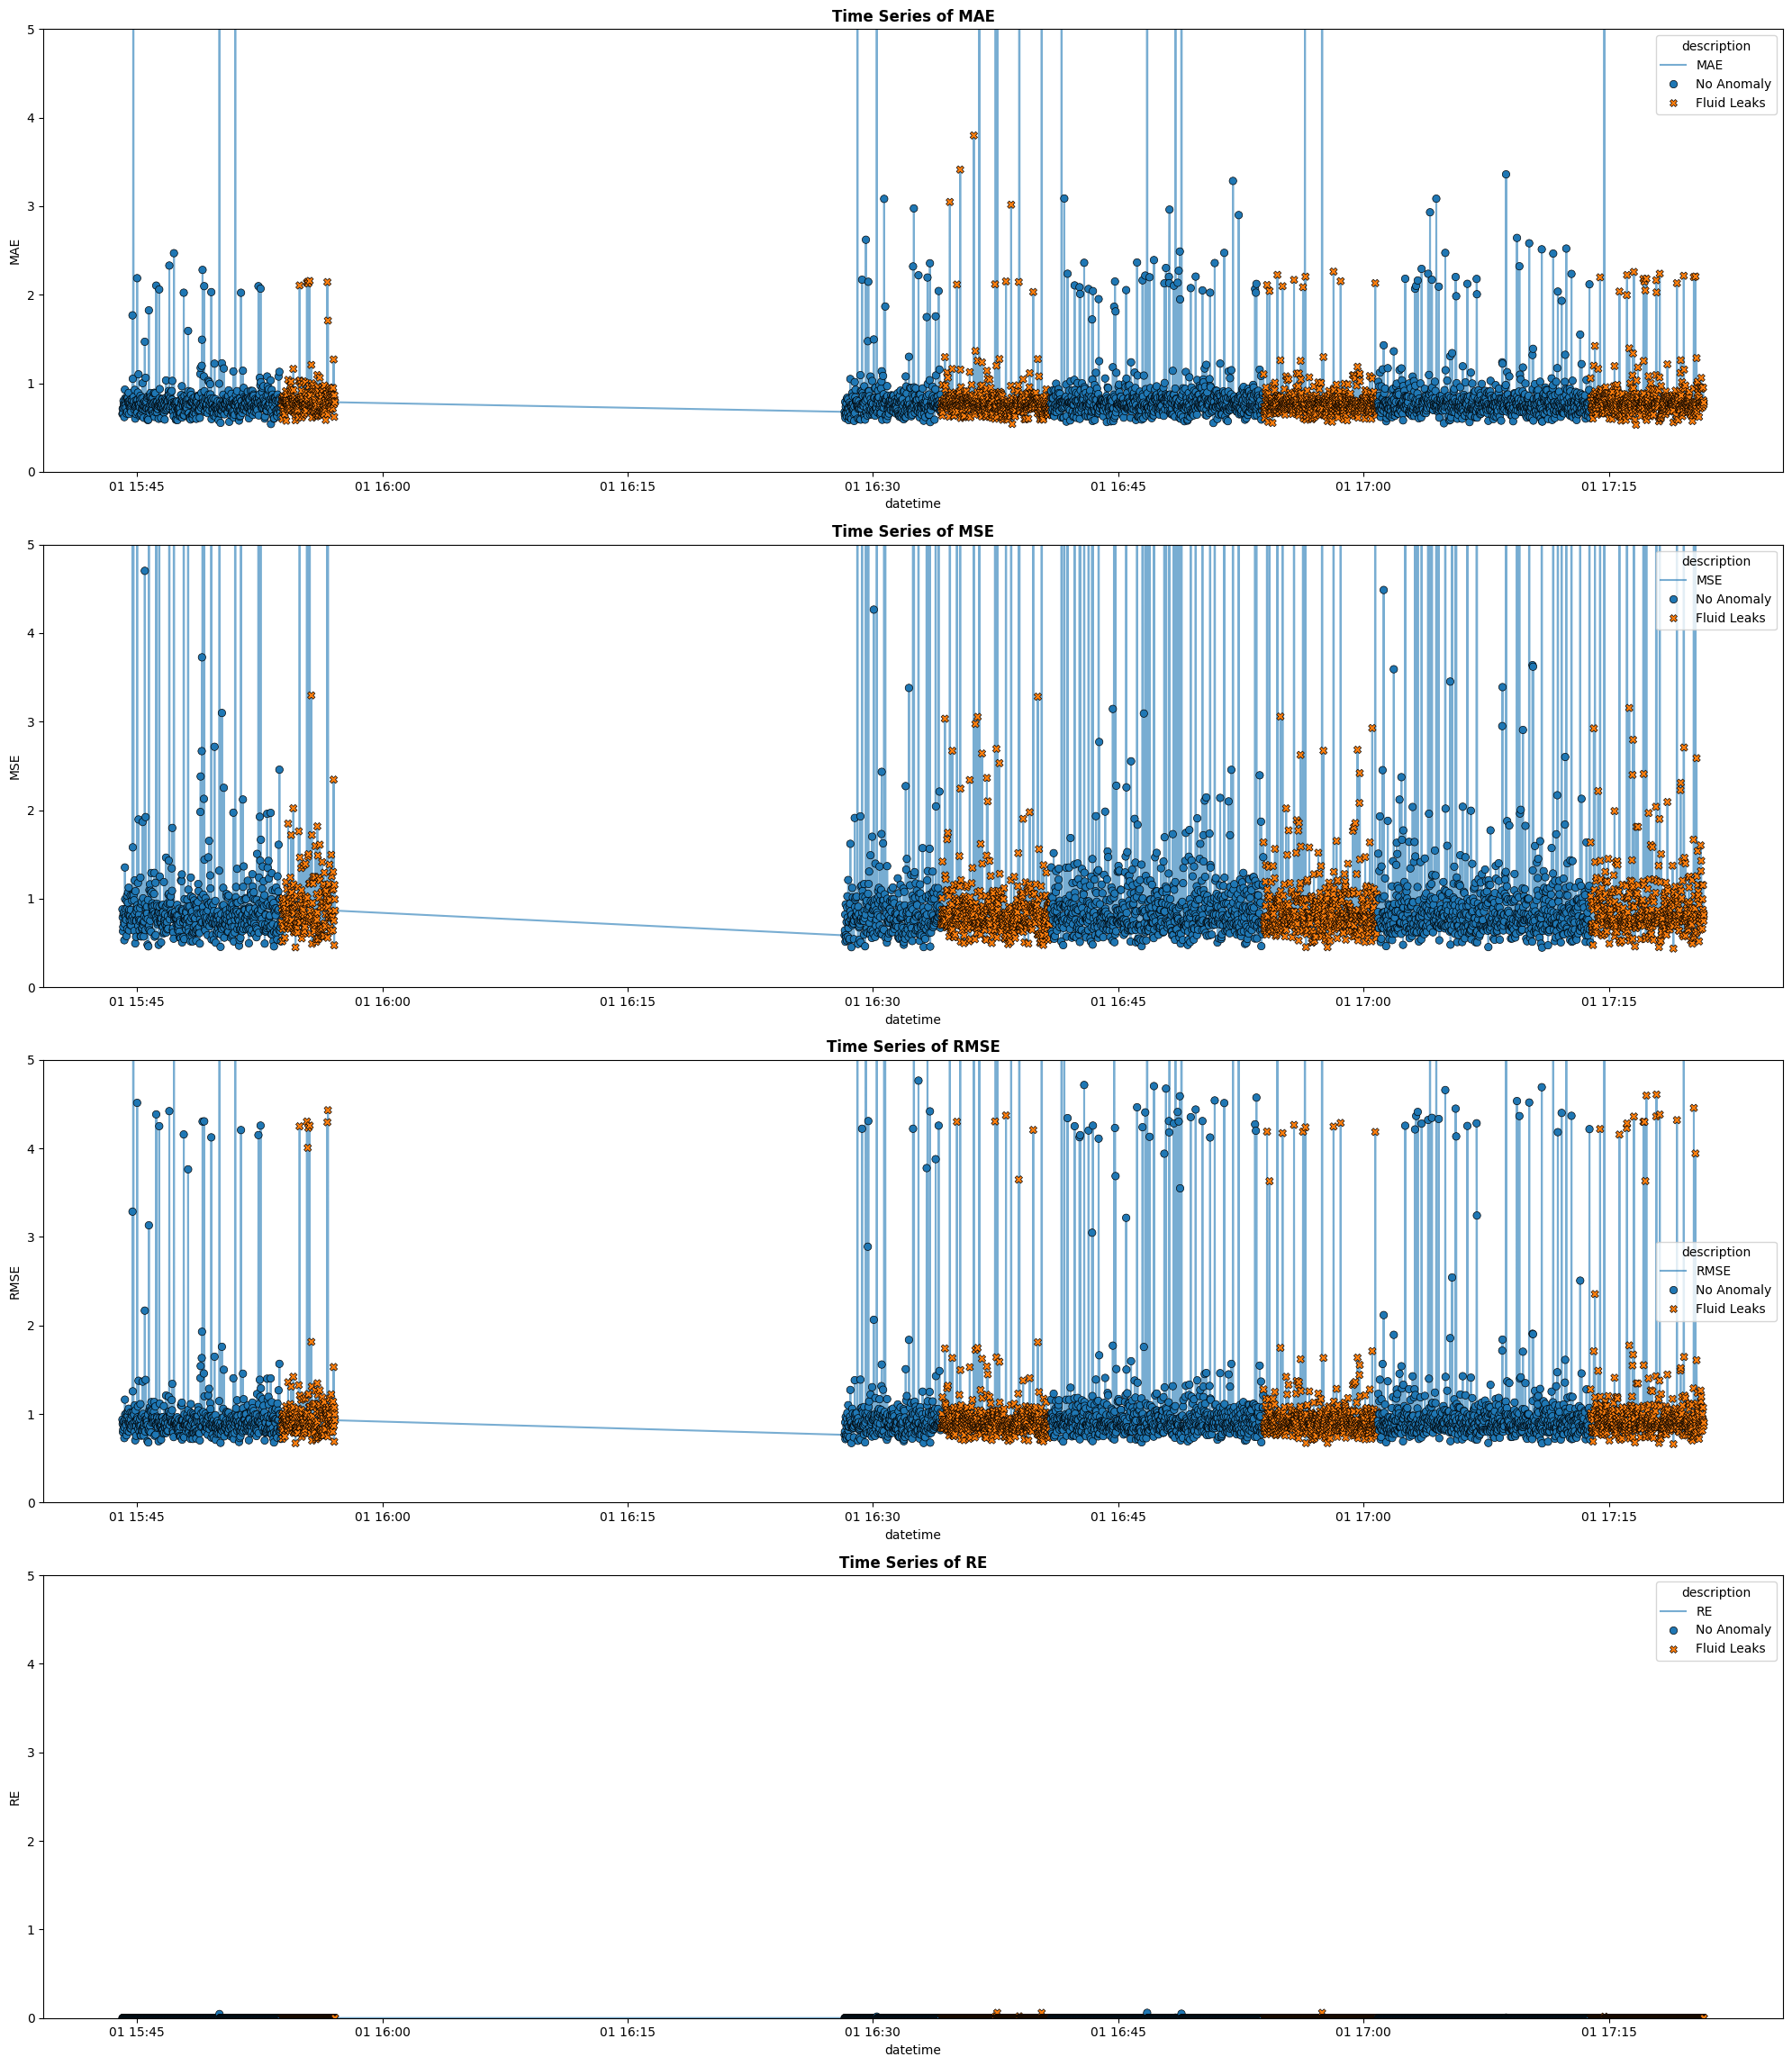

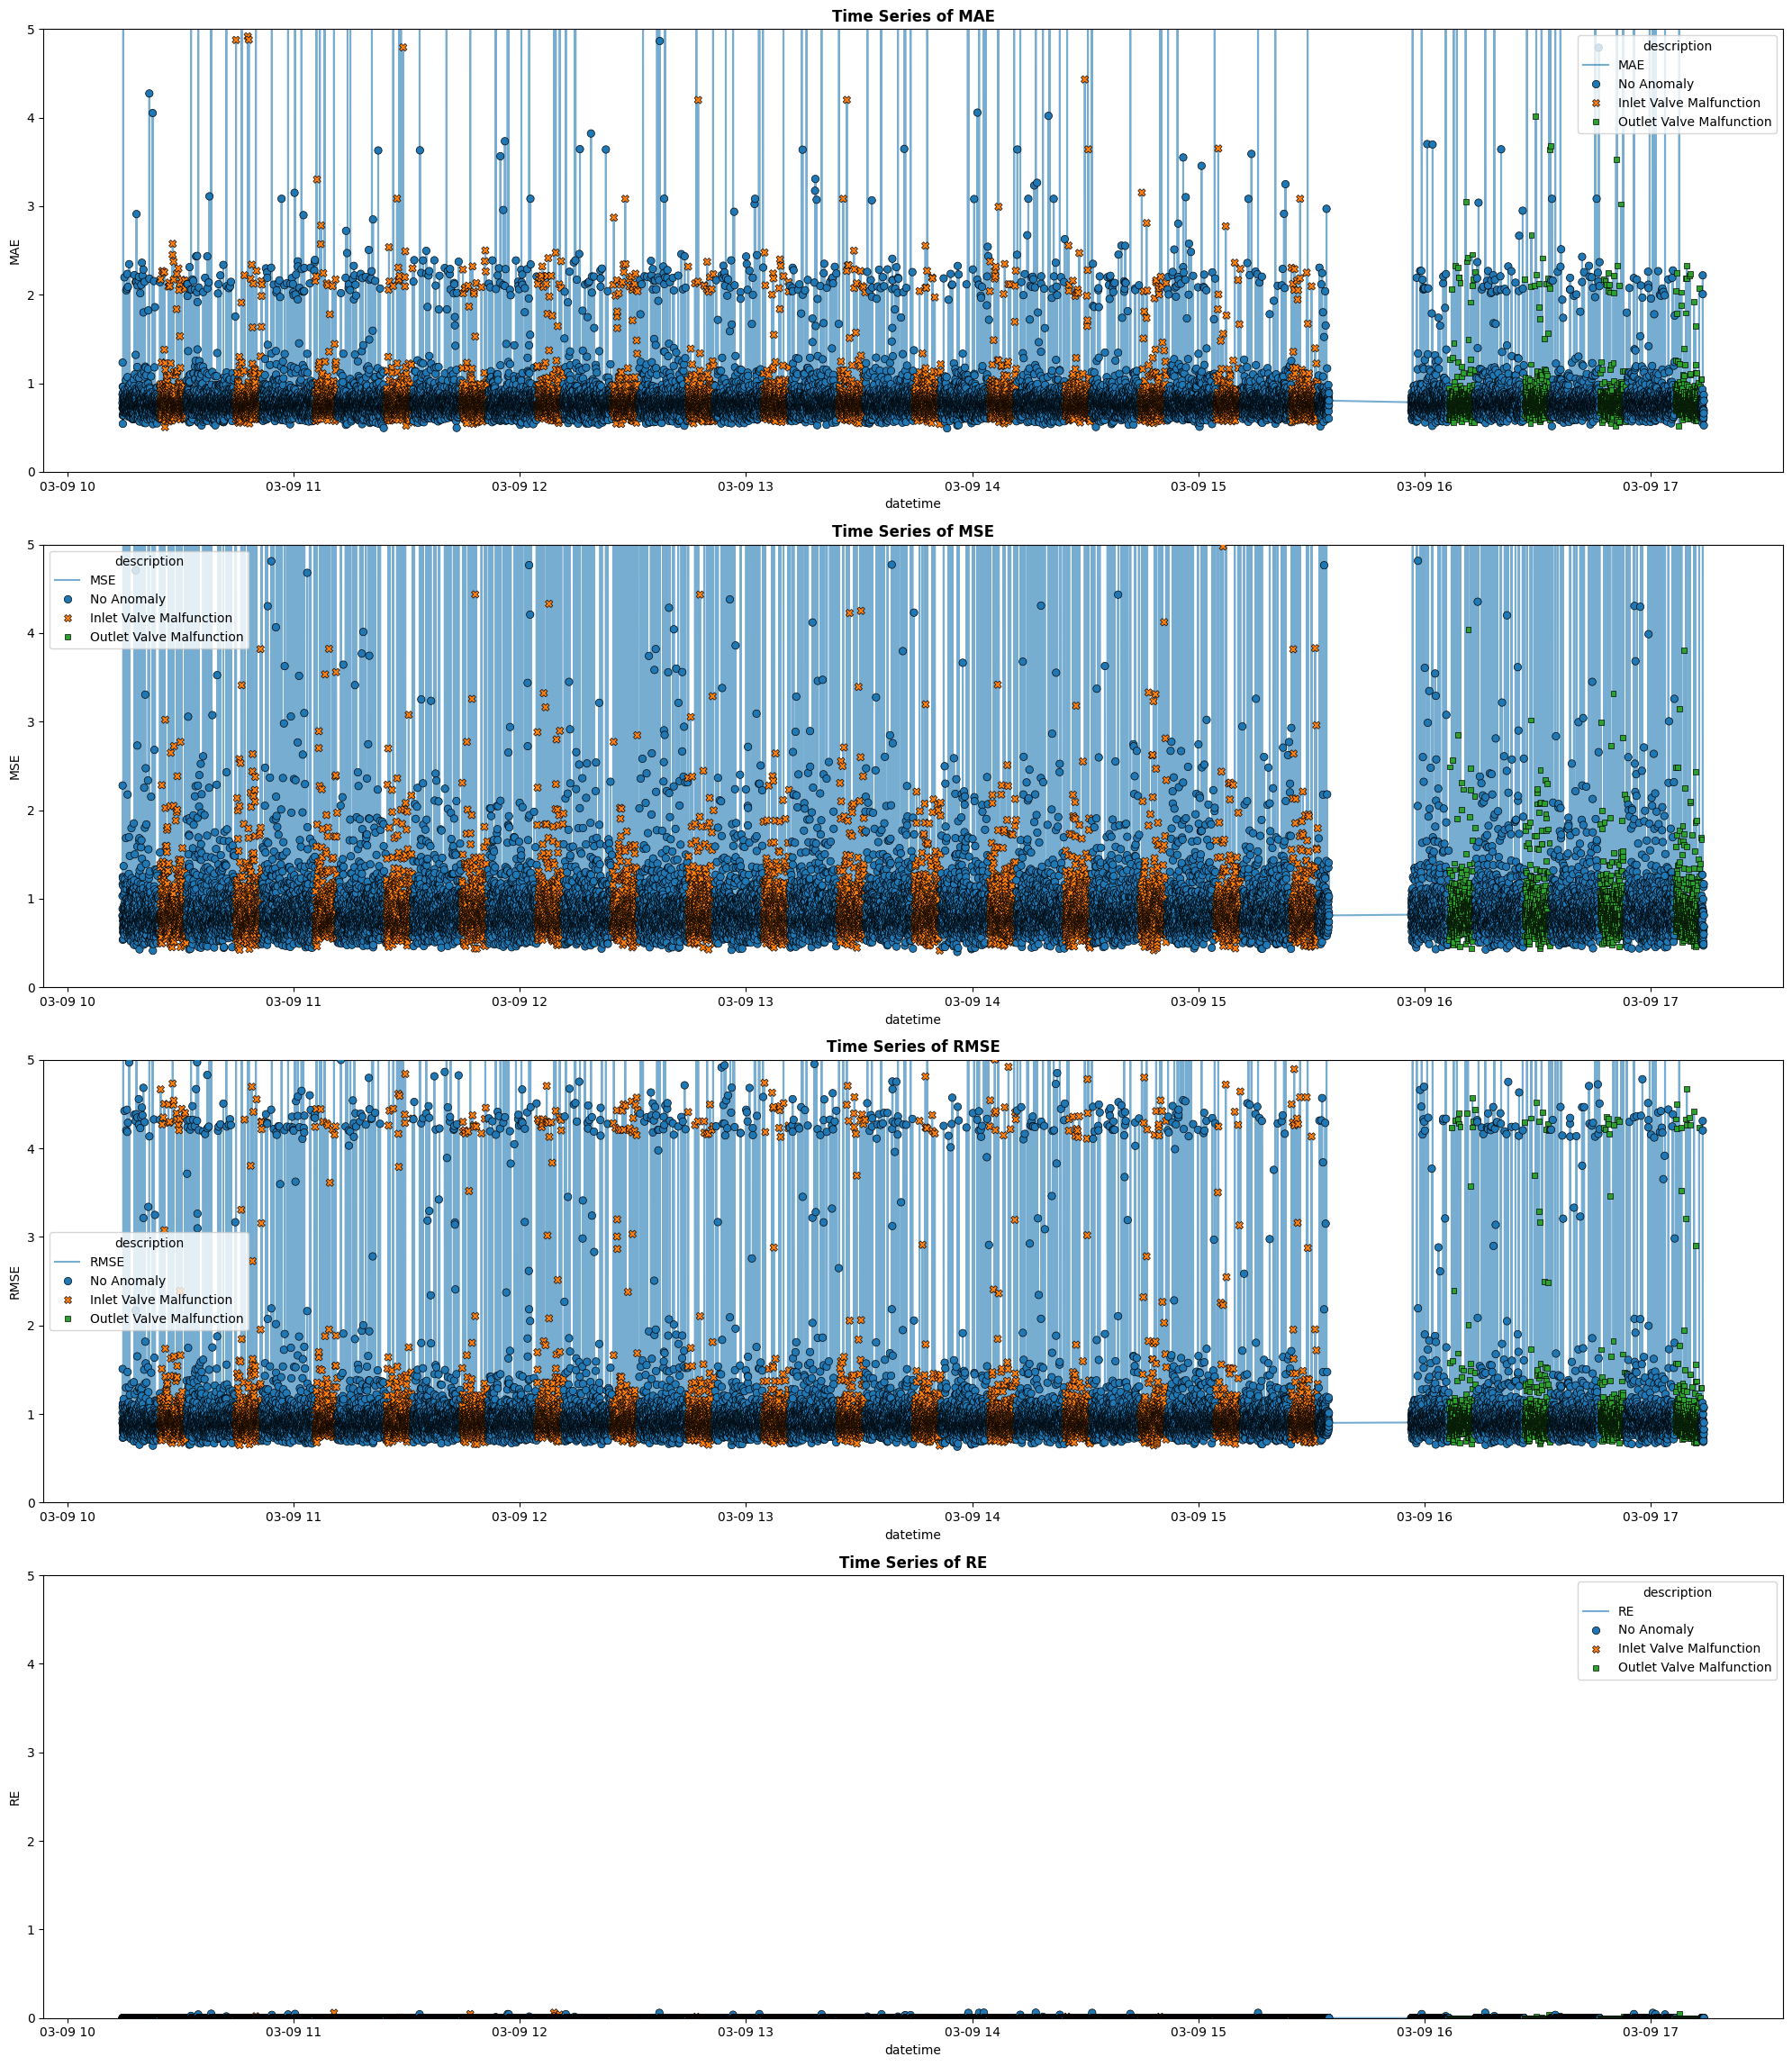

In [34]:
columns = [
            "MAE", 
            "MSE", 
            "RMSE",
            "RE"
]   
plot_timeseries_with_anomaly(
                                reconstructed_loss_dataframe["2020-02-08 00:00:00":"2020-02-08 23:59:59"], 
                                columns=columns, 
                                title="Numerical Parameters with Highlighted Anomalies (2020-02-08)"
)  
plot_timeseries_with_anomaly(
                                reconstructed_loss_dataframe["2020-03-01 00:00:00":"2020-03-01 23:59:59"], 
                                columns=columns, 
                                title="Numerical Parameters with Highlighted Anomalies (2020-03-01)"
)   
plot_timeseries_with_anomaly(
                                reconstructed_loss_dataframe["2020-03-09 00:00:00":"2020-03-09 23:59:59"], 
                                columns=columns, 
                                title="Numerical Parameters with Highlighted Anomalies (2020-03-09)"
)